# ml_B_lasso_codes.ipynb

**文件类型**：配图代码  
**所属章节**：Chapter B 惩罚回归：Lasso、Ridge 与弹性网  
**课程**：《金融数据分析与建模》Part V · 机器学习  
**作者**：连玉君（中山大学岭南学院）  
**最后更新**：2026-04

**本文件用途**：生成 `ml_B_lasso_lec.qmd` 中使用的全部配图，保存至 `figs/` 目录。

**输出文件（8张）**：
- `figs/fig_B_lasso_constraint.png`：Lasso 约束集与 OLS 等高线
- `figs/fig_B_ridge_constraint.png`：Ridge 约束集与 OLS 等高线
- `figs/fig_B_soft_threshold.png`：软阈值 / 硬阈值 / 等比缩放对比
- `figs/fig_B_lasso_path.png`：Lasso 系数路径图
- `figs/fig_B_ridge_path.png`：Ridge 系数路径图
- `figs/fig_B_cv_curve.png`：λ-CV 误差曲线（含 1-SE 规则）
- `figs/fig_B_methods_compare.png`：四种方法系数对比
- `figs/fig_B_subgradient.png`：次导数与软阈值算子

**运行说明**：顺序执行所有 Cell，约 1–2 分钟。


---
## 全局设置


In [1]:
# ════════════════════════════════════════════════════════════════
# 全局设置（每次使用前必须首先运行此 Cell）
# ════════════════════════════════════════════════════════════════
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.getcwd(), '.mplconfig'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV, Ridge, ElasticNet
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
os.makedirs('figs', exist_ok=True)

# ── 中文字体支持 ──────────────────────────────────────────────
from matplotlib import font_manager

candidate_fonts = [
    'Microsoft YaHei', 'SimHei', 'SimSun', 'Arial Unicode MS',
    'Noto Sans CJK SC', 'Source Han Sans SC', 'WenQuanYi Micro Hei'
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
zh_fonts = [f for f in candidate_fonts if f in available_fonts]
ZH_FONT = zh_fonts[0] if zh_fonts else None
if zh_fonts:
    plt.rcParams['font.sans-serif'] = zh_fonts + plt.rcParams['font.sans-serif']
else:
    print('提示：未找到常见中文字体，图中文字可能显示为方框。')
FP = font_manager.FontProperties(family=ZH_FONT) if ZH_FONT else font_manager.FontProperties()
FPB = font_manager.FontProperties(family=ZH_FONT, weight='bold') if ZH_FONT else font_manager.FontProperties(weight='bold')
plt.rcParams['axes.unicode_minus'] = False    # 显示负号


# ── Part V 统一配色常量 ────────────────────────────────────────
C = {
    'primary'  : '#0B3D91',   # 深蓝：主方法/主曲线
    'secondary': '#B8860B',   # 深金黄：对比方法
    'tertiary' : '#2F5E9E',   # 蓝：第三曲线
    'neutral'  : '#878787',   # 灰：参考线
    'highlight': '#6B4E00',   # 深金棕：最优点/关键标注
    'fill'     : '#D6E2F3',   # 浅蓝：填充/阴影
}

# ── 全局图形样式 ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
})

SEED = 42
np.random.seed(SEED)
print('全局设置完成')

全局设置完成


---
## 共用模拟数据

**DGP**：稀疏线性回归，n=300, p=50, s=8（真实非零特征数）


In [2]:
# 生成稀疏回归数据（全章共用）
n, p, s = 300, 50, 8
X_raw, y, coef_true = make_regression(
    n_samples=n, n_features=p, n_informative=s,
    noise=1.0, coef=True, random_state=SEED)

# 标准化（Lasso 必须）
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'数据维度：X={X.shape}, y={y.shape}')
print(f'真实非零系数数量：{(coef_true!=0).sum()}')

数据维度：X=(300, 50), y=(300,)
真实非零系数数量：8


---
## 图1：Lasso 约束集与 OLS 等高线

二维情形下展示 ℓ₁ 约束集（正方形）与 OLS 等高椭圆的切点，
直观说明 Lasso 为何在尖角处产生稀疏解（某个系数恰好为零）。


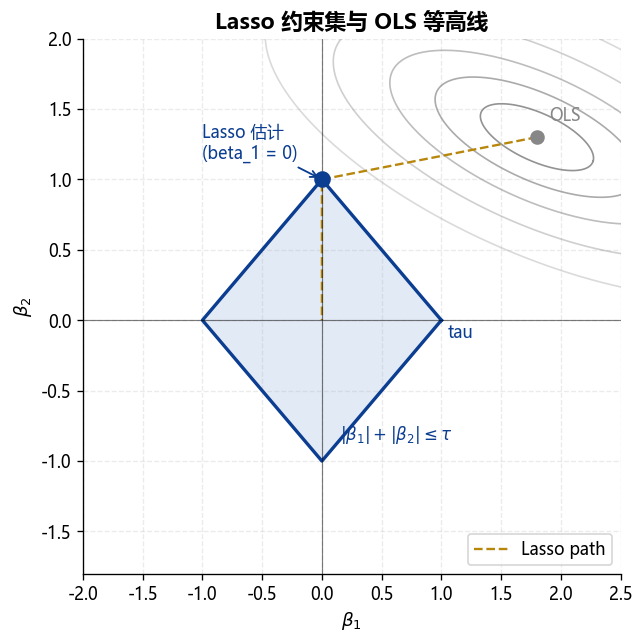

fig_B_lasso_constraint.png 已保存


In [3]:
theta = np.linspace(0, 2*np.pi, 300)
center = np.array([1.8, 1.3])   # 模拟 OLS 解（不在坐标轴上）
tau    = 1.0                     # 约束半径

fig, ax = plt.subplots(figsize=(5.5, 5.5))

# OLS 等高线（旋转椭圆族）
for scale, alpha in zip([0.5,0.9,1.3,1.8,2.4],[0.9,0.7,0.55,0.4,0.3]):
    angle = np.radians(-20)
    ex = scale * 1.0 * np.cos(theta)
    ey = scale * 0.35 * np.sin(theta)
    rx = ex*np.cos(angle) - ey*np.sin(angle) + center[0]
    ry = ex*np.sin(angle) + ey*np.cos(angle) + center[1]
    ax.plot(rx, ry, color=C['neutral'], lw=1.0, alpha=alpha)

# Lasso 约束集：正方形（ℓ₁ 单位球）
sq = np.array([[tau,0],[0,tau],[-tau,0],[0,-tau],[tau,0]])
ax.fill(sq[:,0],sq[:,1], color=C['fill'], alpha=0.7)
ax.plot(sq[:,0],sq[:,1], color=C['primary'], lw=2)

# OLS 点
ax.scatter(*center, color=C['neutral'], s=60, zorder=5)
ax.annotate('OLS', xy=center, xytext=(center[0]+0.1,center[1]+0.12),
            fontproperties=FP, fontsize=10, color=C['neutral'])

# Lasso 解：切点在尖角（坐标轴上）
lasso_sol = np.array([0.0, tau])
ax.scatter(*lasso_sol, color=C['primary'], s=80, zorder=6)
ax.annotate('Lasso 估计\n(beta_1 = 0)', xy=lasso_sol,
            xytext=(-1.0,1.15), fontproperties=FP, fontsize=10, color=C['primary'],
            arrowprops=dict(arrowstyle='->', color=C['primary'], lw=1.1))

# Lasso path（虚线：从 OLS 到尖角）
path = np.array([[center[0],center[1]],[0.0,tau],[0.0,0.0]])
ax.plot(path[:,0],path[:,1], ls='--', color=C['secondary'], lw=1.4, label='Lasso path')

ax.text(tau+0.05,-0.12,'tau', fontproperties=FP, fontsize=10, color=C['primary'])
ax.text(0.15,-0.85,r'$|\beta_1|+|\beta_2| \leq \tau$',
        fontproperties=FP, fontsize=10, color=C['primary'])
ax.axhline(0,color='black',lw=0.7,alpha=0.5)
ax.axvline(0,color='black',lw=0.7,alpha=0.5)
ax.set_xlim(-2.0,2.5); ax.set_ylim(-1.8,2.0)
ax.set_xlabel(r'$\beta_1$', fontproperties=FP, fontsize=11)
ax.set_ylabel(r'$\beta_2$', fontproperties=FP, fontsize=11)
ax.set_title('Lasso 约束集与 OLS 等高线', fontproperties=FPB, fontsize=13)
ax.legend(prop=FP, loc='lower right')
fig.tight_layout()
fig.savefig('figs/fig_B_lasso_constraint.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_lasso_constraint.png 已保存')

---
## 图2：Ridge 约束集与 OLS 等高线

岭回归的约束集是圆形（无尖角），切点通常不落在坐标轴上，
因此岭回归不能产生零系数（不具有变量筛选功能）。


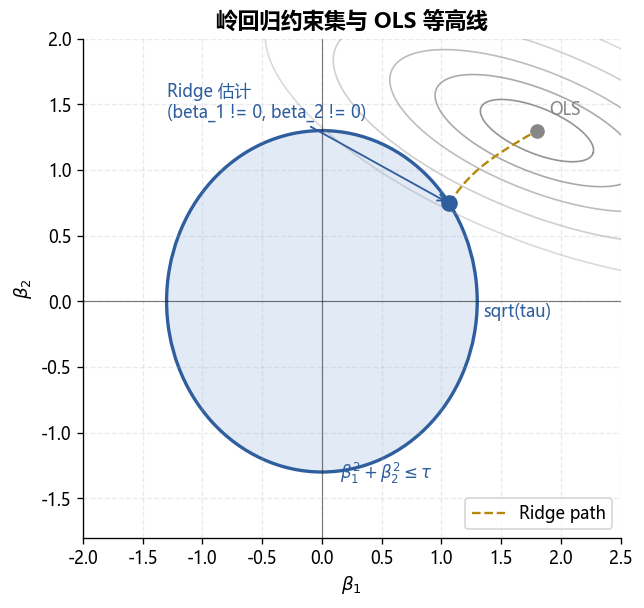

fig_B_ridge_constraint.png 已保存


In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5.2))

# 同样的 OLS 等高线
for scale, alpha in zip([0.5,0.9,1.3,1.8,2.4],[0.9,0.7,0.55,0.4,0.3]):
    angle = np.radians(-20)
    ex = scale * 1.0 * np.cos(theta)
    ey = scale * 0.35 * np.sin(theta)
    rx = ex*np.cos(angle) - ey*np.sin(angle) + center[0]
    ry = ex*np.sin(angle) + ey*np.cos(angle) + center[1]
    ax.plot(rx, ry, color=C['neutral'], lw=1.0, alpha=alpha)

# Ridge 约束集：圆形
r_radius = tau * 1.3
circle = plt.Circle((0,0), r_radius, color=C['fill'], alpha=0.7)
ax.add_patch(circle)
circle_border = plt.Circle((0,0), r_radius, fill=False, color=C['tertiary'], lw=2)
ax.add_patch(circle_border)

# OLS 点
ax.scatter(*center, color=C['neutral'], s=60, zorder=5)
ax.annotate('OLS', xy=center, xytext=(center[0]+0.1,center[1]+0.12),
            fontproperties=FP, fontsize=10, color=C['neutral'])

# Ridge 解：在圆内部（两个系数均不为零）
angle_r = np.radians(35)
ridge_sol = r_radius * np.array([np.cos(angle_r), np.sin(angle_r)])
ax.scatter(*ridge_sol, color=C['tertiary'], s=80, zorder=6)
ax.annotate('Ridge 估计\n(beta_1 != 0, beta_2 != 0)',
            xy=ridge_sol, xytext=(-1.3,1.4),
            fontproperties=FP, fontsize=10, color=C['tertiary'],
            arrowprops=dict(arrowstyle='->', color=C['tertiary'], lw=1.1))

# Ridge path（曲线）
t_p = np.linspace(0,1,50)
rpx = center[0]*t_p + ridge_sol[0]*(1-t_p) - 0.1*np.sin(np.pi*t_p)
rpy = center[1]*t_p + ridge_sol[1]*(1-t_p)
ax.plot(rpx, rpy, ls='--', color=C['secondary'], lw=1.4, label='Ridge path')

ax.text(r_radius+0.05,-0.12,'sqrt(tau)', fontproperties=FP, fontsize=10, color=C['tertiary'])
ax.text(0.15,-1.35,r'$\beta_1^2+\beta_2^2 \leq \tau$',
        fontproperties=FP, fontsize=10, color=C['tertiary'])
ax.axhline(0,color='black',lw=0.7,alpha=0.5)
ax.axvline(0,color='black',lw=0.7,alpha=0.5)
ax.set_xlim(-2.0,2.5); ax.set_ylim(-1.8,2.0)
ax.set_xlabel(r'$\beta_1$', fontproperties=FP, fontsize=11)
ax.set_ylabel(r'$\beta_2$', fontproperties=FP, fontsize=11)
ax.set_title('岭回归约束集与 OLS 等高线', fontproperties=FPB, fontsize=13)
ax.legend(prop=FP, loc='lower right')
fig.tight_layout()
fig.savefig('figs/fig_B_ridge_constraint.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_ridge_constraint.png 已保存')

---
## 图3：软阈值 / 硬阈值 / 等比缩放对比

正交情形（X'X = I）下，三种方法（Lasso、最优子集、Ridge）的系数变换方式。
软阈值（Lasso）：连续但在零处截断。硬阈值（最优子集）：不连续跳跃。等比缩放（Ridge）：不产生零值。


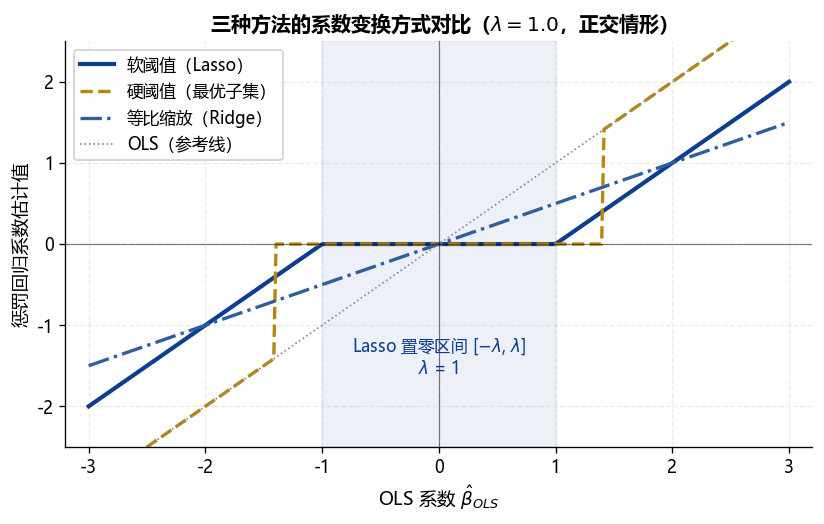

fig_B_soft_threshold.png 已保存


In [5]:
lam = 1.0
beta_ols = np.linspace(-3, 3, 300)

# 三种变换
soft   = np.sign(beta_ols) * np.maximum(np.abs(beta_ols) - lam, 0)
hard   = np.where(np.abs(beta_ols) > np.sqrt(2*lam), beta_ols, 0)
ridge_s = beta_ols / (1 + lam)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(beta_ols, soft,    color=C['primary'],   lw=2.5, label='软阈值（Lasso）')
ax.plot(beta_ols, hard,    color=C['secondary'], lw=2.0, ls='--', label='硬阈值（最优子集）')
ax.plot(beta_ols, ridge_s, color=C['tertiary'],  lw=2.0, ls='-.', label='等比缩放（Ridge）')
ax.plot(beta_ols, beta_ols, color=C['neutral'],  lw=1.0, ls=':', label='OLS（参考线）')

# 标注 Lasso 置零区间
ax.axvspan(-lam, lam, alpha=0.07, color=C['primary'])
ax.text(0, -1.6, f'Lasso 置零区间 [$-\\lambda$, $\\lambda$]\n$\\lambda$ = {lam:.0f}',
        fontproperties=FP, fontsize=10, ha='center', color=C['primary'])

ax.axhline(0, color='black', lw=0.7, alpha=0.5)
ax.axvline(0, color='black', lw=0.7, alpha=0.5)
ax.set_xlabel(r'OLS 系数 $\hat{\beta}_{OLS}$', fontproperties=FP, fontsize=11)
ax.set_ylabel('惩罚回归系数估计值', fontproperties=FP, fontsize=11)
ax.set_title('三种方法的系数变换方式对比（$\\lambda=1.0$，正交情形）',
             fontproperties=FPB, fontsize=12)
ax.legend(prop=FP, loc='upper left', framealpha=0.9)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-2.5, 2.5)
fig.tight_layout()
fig.savefig('figs/fig_B_soft_threshold.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_soft_threshold.png 已保存')

---
## 图4：Lasso 系数路径图

横轴为 ℓ₁ 范数相对比率（0 = 全零模型，1 = OLS）。
随 lambda 增大，系数依次收缩至零——最后保留的变量最重要。
垂直虚线为 CV 选出的最优 lambda。


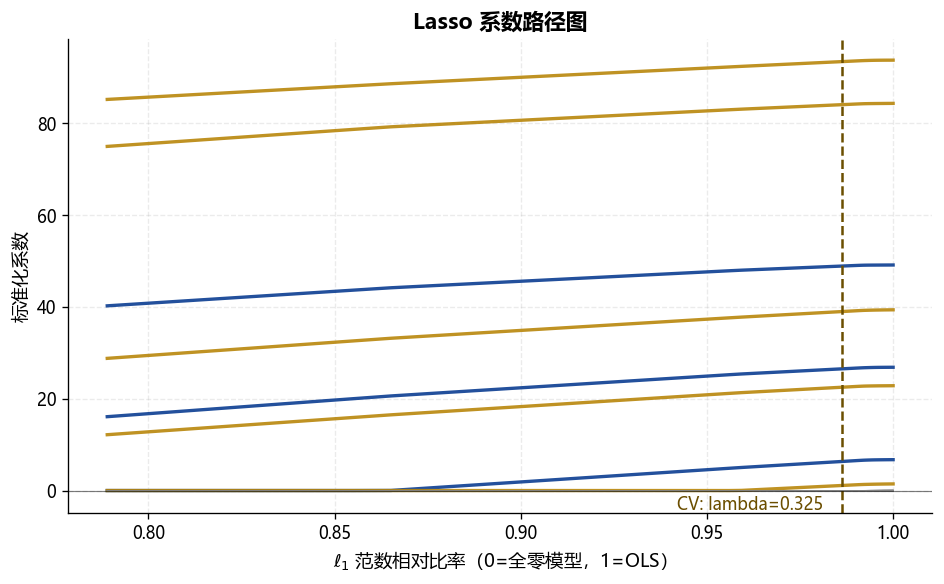

fig_B_lasso_path.png 已保存  （最优 lambda=0.3252，非零系数=8）


In [6]:
# 沿 lambda 序列逐一拟合 Lasso，记录系数
alphas_lasso = np.logspace(-3, 1, 100)
coefs_lasso  = []
for a in alphas_lasso:
    mdl = Lasso(alpha=a, max_iter=5000, random_state=SEED)
    mdl.fit(X, y)
    coefs_lasso.append(mdl.coef_.copy())
coefs_lasso = np.array(coefs_lasso)   # shape: (100, p)

# 用 LassoCV 找到最优 lambda
lasso_cv = LassoCV(cv=10, n_alphas=100, random_state=SEED, max_iter=5000)
lasso_cv.fit(X, y)
best_alpha = lasso_cv.alpha_

# ℓ₁ 范数相对比率（横轴）
l1_norms     = np.abs(coefs_lasso).sum(axis=1)
l1_norms_rel = l1_norms / l1_norms.max()

fig, ax = plt.subplots(figsize=(8, 5))
for j in range(p):
    is_true = abs(coef_true[j]) > 0.1  # 真实非零系数（显示更粗）
    col = C['primary'] if (is_true and j % 2 == 0) else (C['secondary'] if is_true else C['neutral'])
    ax.plot(l1_norms_rel, coefs_lasso[:,j],
            lw=2.0 if is_true else 0.6,
            alpha=0.9 if is_true else 0.3,
            color=col)

# 标注最优 lambda 的位置
best_coef = Lasso(alpha=best_alpha, max_iter=5000).fit(X,y).coef_
best_l1   = np.abs(best_coef).sum() / l1_norms.max()
ax.axvline(best_l1, color=C['highlight'], lw=1.5, ls='--')
ax.text(best_l1-0.005, ax.get_ylim()[0]*0.85 if ax.get_ylim()[0]<0 else 1,
        f'CV: lambda={best_alpha:.3f}', fontproperties=FP, fontsize=10,
        ha='right', color=C['highlight'])

ax.axhline(0, color='black', lw=0.7, alpha=0.5)
ax.set_xlabel(r'$\ell_1$ 范数相对比率（0=全零模型，1=OLS）', fontproperties=FP, fontsize=11)
ax.set_ylabel('标准化系数', fontproperties=FP, fontsize=11)
ax.set_title('Lasso 系数路径图', fontproperties=FPB, fontsize=13)
fig.tight_layout()
fig.savefig('figs/fig_B_lasso_path.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'fig_B_lasso_path.png 已保存  （最优 lambda={best_alpha:.4f}，'
      f'非零系数={( best_coef!=0).sum()}）')

---
## 图5：Ridge 系数路径图

与 Lasso 不同：所有系数同步向零收缩，但永远不会恰好为零。


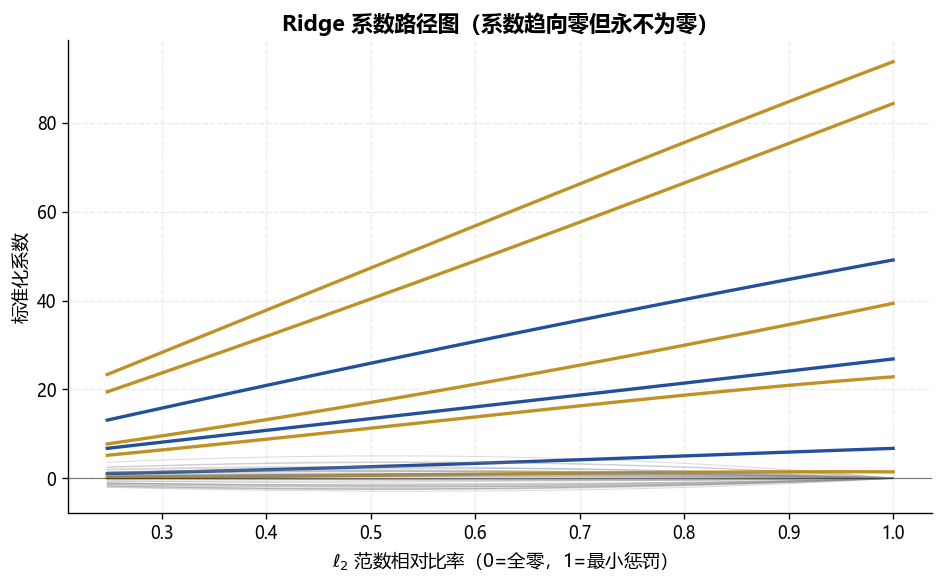

fig_B_ridge_path.png 已保存


In [7]:
alphas_ridge = np.logspace(-2, 3, 100)
coefs_ridge  = []
for a in alphas_ridge:
    mdl = Ridge(alpha=a)
    mdl.fit(X, y)
    coefs_ridge.append(mdl.coef_.copy())
coefs_ridge = np.array(coefs_ridge)

l2_norms     = np.sqrt((coefs_ridge**2).sum(axis=1))
l2_norms_rel = l2_norms / l2_norms.max()

fig, ax = plt.subplots(figsize=(8, 5))
for j in range(p):
    is_true = abs(coef_true[j]) > 0.1
    col = C['primary'] if (is_true and j % 2 == 0) else (C['secondary'] if is_true else C['neutral'])
    ax.plot(l2_norms_rel, coefs_ridge[:,j],
            lw=2.0 if is_true else 0.6,
            alpha=0.9 if is_true else 0.3,
            color=col)

ax.axhline(0, color='black', lw=0.7, alpha=0.5)
ax.set_xlabel(r'$\ell_2$ 范数相对比率（0=全零，1=最小惩罚）', fontproperties=FP, fontsize=11)
ax.set_ylabel('标准化系数', fontproperties=FP, fontsize=11)
ax.set_title('Ridge 系数路径图（系数趋向零但永不为零）', fontproperties=FPB, fontsize=13)
fig.tight_layout()
fig.savefig('figs/fig_B_ridge_path.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_ridge_path.png 已保存')

---
## 图6：λ-CV 误差曲线（含 1-SE 规则）

展示如何通过 CV 曲线选择最优 lambda：
- 左侧虚线：CV 误差最小处（最优 lambda）
- 右侧虚线：1-SE 规则对应的 lambda（更精简的模型）


最优 lambda=0.3953，非零系数=8
1-SE  lambda=0.1065，非零系数=10（更精简）


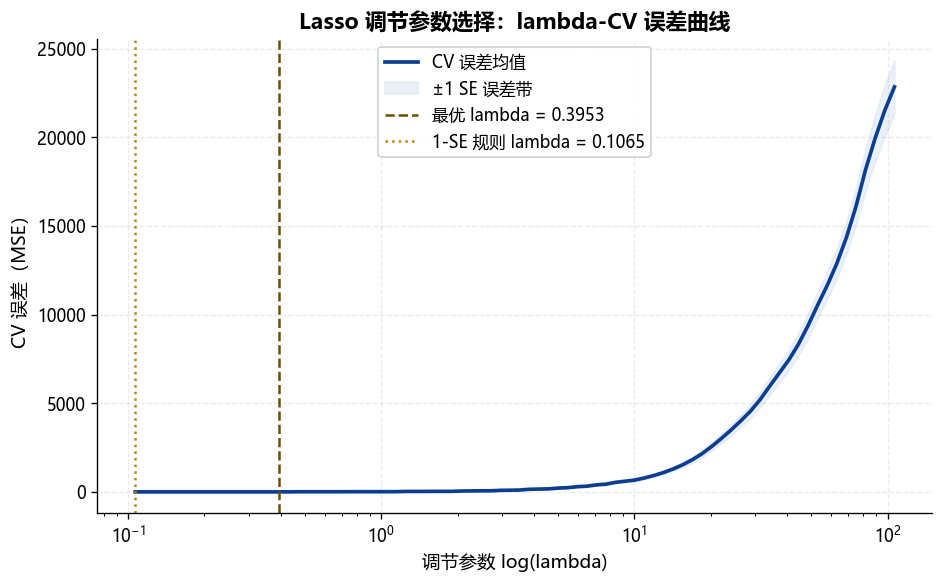

fig_B_cv_curve.png 已保存


In [8]:
# 拟合 LassoCV，获取全部 lambda 的 CV 误差
lasso_cv2 = LassoCV(cv=10, n_alphas=80, random_state=SEED, max_iter=5000)
lasso_cv2.fit(X, y)

alphas_cv = lasso_cv2.alphas_
mse_path  = lasso_cv2.mse_path_           # shape: (n_alphas, K)
mse_mean  = mse_path.mean(axis=1)
mse_std   = mse_path.std(axis=1) / np.sqrt(mse_path.shape[1])  # 标准误

# 最优 lambda（CV 误差最小）
best_idx = np.argmin(mse_mean)
best_a   = alphas_cv[best_idx]

# 1-SE 规则：在 best_mse + 1*SE 以内选最大 lambda（最精简模型）
threshold = mse_mean[best_idx] + mse_std[best_idx]
idx_1se   = np.where(mse_mean <= threshold)[0]
a_1se     = alphas_cv[idx_1se[-1]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(alphas_cv, mse_mean, color=C['primary'], lw=2.2, label='CV 误差均值')
ax.fill_between(alphas_cv,
                mse_mean - mse_std,
                mse_mean + mse_std,
                color=C['fill'], alpha=0.5, label='±1 SE 误差带')

ax.axvline(best_a, color=C['highlight'], lw=1.5, ls='--',
           label=f'最优 lambda = {best_a:.4f}')
ax.axvline(a_1se, color=C['secondary'], lw=1.5, ls=':',
           label=f'1-SE 规则 lambda = {a_1se:.4f}')

ax.set_xlabel('调节参数 log(lambda)', fontproperties=FP, fontsize=11)
ax.set_ylabel('CV 误差（MSE）', fontproperties=FP, fontsize=11)
ax.set_title('Lasso 调节参数选择：lambda-CV 误差曲线', fontproperties=FPB, fontsize=13)
ax.legend(prop=FP, framealpha=0.9)

# 打印两种规则对应的非零系数数量
n_best = (Lasso(alpha=best_a,max_iter=5000).fit(X,y).coef_!=0).sum()
n_1se  = (Lasso(alpha=a_1se, max_iter=5000).fit(X,y).coef_!=0).sum()
print(f'最优 lambda={best_a:.4f}，非零系数={n_best}')
print(f'1-SE  lambda={a_1se:.4f}，非零系数={n_1se}（更精简）')

fig.tight_layout()
fig.savefig('figs/fig_B_cv_curve.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_cv_curve.png 已保存')

---
## 图7：四种方法系数估计对比

在同一数据集上对比 OLS、Ridge、弹性网、Lasso 的系数分布，
直观展示各方法的收缩行为和稀疏性差异。


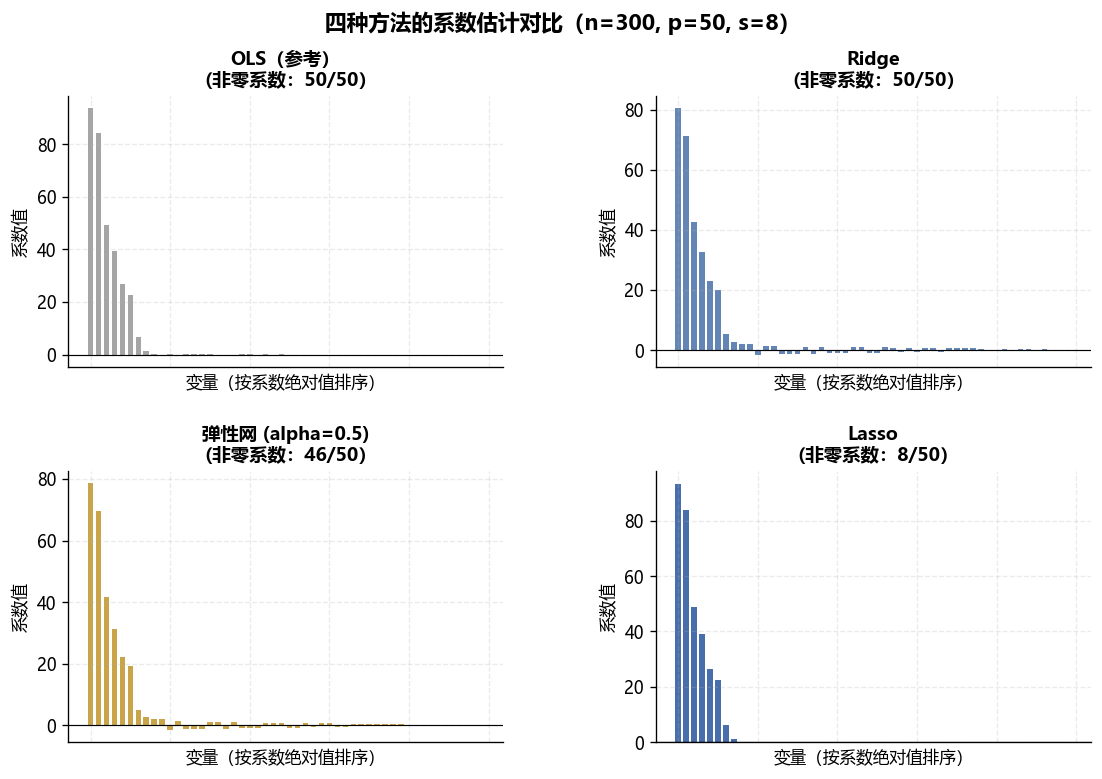

fig_B_methods_compare.png 已保存


In [9]:
# 拟合四种方法
ols_coef  = np.linalg.lstsq(X, y, rcond=None)[0]
ridge_fit = Ridge(alpha=50).fit(X, y)
enet_fit  = ElasticNet(alpha=best_a, l1_ratio=0.5, max_iter=5000,
                       random_state=SEED).fit(X, y)
lasso_fit = Lasso(alpha=best_a, max_iter=5000, random_state=SEED).fit(X, y)

coef_dict = {
    'OLS（参考）' : ols_coef,
    'Ridge'       : ridge_fit.coef_,
    '弹性网 (alpha=0.5)': enet_fit.coef_,
    'Lasso'       : lasso_fit.coef_,
}
colors_map = [C['neutral'], C['tertiary'], C['secondary'], C['primary']]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.subplots_adjust(hspace=0.38, wspace=0.35)

for ax, (label, coef), col in zip(axes.flat, coef_dict.items(), colors_map):
    idx = np.argsort(np.abs(coef))[::-1]  # 按系数绝对值排序
    ax.bar(range(p), coef[idx], color=col, alpha=0.75, width=0.7)
    ax.axhline(0, color='black', lw=0.7)
    nonzero = (coef != 0).sum()
    ax.set_title(f'{label}\n（非零系数：{nonzero}/{p}）',
                 fontproperties=FPB, fontsize=11)
    ax.set_xlabel('变量（按系数绝对值排序）', fontproperties=FP, fontsize=10)
    ax.set_ylabel('系数值', fontproperties=FP, fontsize=10)
    ax.tick_params(bottom=False, labelbottom=False)

fig.suptitle('四种方法的系数估计对比（n=300, p=50, s=8）',
             fontproperties=FPB, fontsize=13)
fig.savefig('figs/fig_B_methods_compare.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_methods_compare.png 已保存')

---
## 图8：次导数与软阈值算子

左图：|x| 在 x=0 处不可微，其次微分为区间 [-1, 1]（红色竖线段）。
右图：软阈值算子的形状——绝对值小于 lambda 的系数被置零，其余向零移动 lambda。


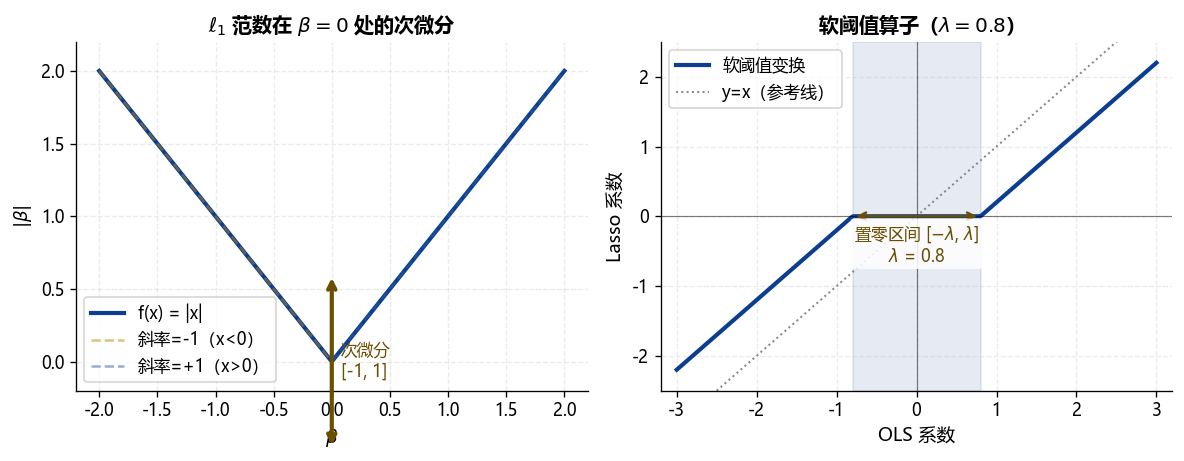

fig_B_subgradient.png 已保存


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 左图：|x| 的次微分
x_v = np.linspace(-2, 2, 300)
ax  = axes[0]
ax.plot(x_v, np.abs(x_v), color=C['primary'], lw=2.5, label='f(x) = |x|')
ax.annotate('', xy=(0,0.6), xytext=(0,-0.6),
            arrowprops=dict(arrowstyle='<->', color=C['highlight'], lw=2.5))
ax.text(0.08, 0, '次微分\n[-1, 1]', fontproperties=FP, fontsize=10,
        va='center', color=C['highlight'])
ax.plot([-2,0],[2,0], color=C['secondary'],lw=1.5,ls='--',alpha=0.5, label='斜率=-1（x<0）')
ax.plot([0,2], [0,2], color=C['tertiary'], lw=1.5,ls='--',alpha=0.5, label='斜率=+1（x>0）')
ax.set_xlim(-2.2,2.2); ax.set_ylim(-0.2,2.2)
ax.set_xlabel(r'$\beta$', fontproperties=FP, fontsize=11)
ax.set_ylabel(r'$|\beta|$', fontproperties=FP, fontsize=11)
ax.set_title(r'$\ell_1$ 范数在 $\beta=0$ 处的次微分', fontproperties=FPB, fontsize=12)
ax.legend(prop=FP, fontsize=10)

# 右图：软阈值算子
x_v2 = np.linspace(-3, 3, 300)
lam_st = 0.8
soft_v = np.sign(x_v2) * np.maximum(np.abs(x_v2)-lam_st, 0)
ax2 = axes[1]
ax2.plot(x_v2, soft_v,  color=C['primary'], lw=2.5, label='软阈值变换')
ax2.plot(x_v2, x_v2,   color=C['neutral'], lw=1.2, ls=':', label='y=x（参考线）')
ax2.axvspan(-lam_st, lam_st, alpha=0.1, color=C['primary'])
ax2.annotate('', xy=(lam_st,0), xytext=(-lam_st,0),
             arrowprops=dict(arrowstyle='<->', color=C['highlight'], lw=1.5))
ax2.text(0, -0.65, f'置零区间 [$-\\lambda$, $\\lambda$]\n$\\lambda$ = {lam_st}',
         fontproperties=FP, fontsize=10, ha='center', color=C['highlight'],
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
ax2.set_xlim(-3.2,3.2); ax2.set_ylim(-2.5,2.5)
ax2.axhline(0,color='black',lw=0.7,alpha=0.5)
ax2.axvline(0,color='black',lw=0.7,alpha=0.5)
ax2.set_xlabel('OLS 系数', fontproperties=FP, fontsize=11)
ax2.set_ylabel('Lasso 系数', fontproperties=FP, fontsize=11)
ax2.set_title(f'软阈值算子（$\\lambda={lam_st}$）', fontproperties=FPB, fontsize=12)
ax2.legend(prop=FP)

fig.tight_layout()
fig.savefig('figs/fig_B_subgradient.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('fig_B_subgradient.png 已保存')

---
## 汇总确认


In [11]:
print('\n' + '='*55)
print('Chapter B codes.ipynb 所有图形生成完成')
figs_b = [f for f in sorted(os.listdir('figs')) if f.startswith('fig_B')]
for f in figs_b:
    sz = os.path.getsize(f'figs/{f}') // 1024
    print(f'  {f}  ({sz} KB)')
print()
print('在 ml_B_lasso_lec.qmd 中引用方式示例：')
print('  ![图注](figs/fig_B_lasso_constraint.png){#fig-B-lasso-constraint}')


Chapter B codes.ipynb 所有图形生成完成
  fig_B_cv_curve.png  (80 KB)
  fig_B_lasso_constraint.png  (85 KB)
  fig_B_lasso_path.png  (65 KB)
  fig_B_methods_compare.png  (91 KB)
  fig_B_ridge_constraint.png  (92 KB)
  fig_B_ridge_path.png  (107 KB)
  fig_B_soft_threshold.png  (94 KB)
  fig_B_subgradient.png  (102 KB)

在 ml_B_lasso_lec.qmd 中引用方式示例：
  ![图注](figs/fig_B_lasso_constraint.png){#fig-B-lasso-constraint}
